## ARBITRARY VALUE IMPUTATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('titanic_toy (1).csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


### Perform Train Test Split

In [5]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)
x_train.shape, x_test.shape

((712, 3), (179, 3))

In [7]:
x_train['Age_99'] = x_train['Age'].fillna(99)
x_train['Age_minusl'] = x_train['Age'].fillna(-1)

x_train['Fare_999'] = x_train['Fare'].fillna(999)
x_train['Fare_minusl'] = x_train['Fare'].fillna(-1)

### Creating new Column and Replace Value (Age-99 | Fare-999)

In [9]:
x_train['Age_99'] = x_train['Age'].fillna(99)
x_train['Age_minusl'] = x_train['Age'].fillna(-1)

x_train['Fare_999'] = x_train['Fare'].fillna(999)
x_train['Fare_minusl'] = x_train['Fare'].fillna(-1)

In [10]:
x_train.sample(8)

,Age,Fare,Family,Age_99,Age_minusl,Fare_999,Fare_minusl
359,NaN,7.8792,0,99.0,-1.0,7.8792,7.8792
31,NaN,146.5208,1,99.0,-1.0,146.5208,146.5208
191,19.0,13.0000,0,19.0,19.0,13.0000,13.0000
432,42.0,26.0000,1,42.0,42.0,26.0000,26.0000
314,43.0,26.2500,2,43.0,43.0,26.2500,26.2500
766,NaN,39.6000,0,99.0,-1.0,39.6000,39.6000
224,38.0,90.0000,1,38.0,38.0,90.0000,90.0000
855,18.0,9.3500,1,18.0,18.0,9.3500,9.3500


### Review Variance

In [15]:
print('Original Age variable variance: ', x_train['Age'].var())
print('Age Variance after 99 use imputation: ', x_train['Age_99'].var())
print('Age variance after -1 use imputation: ', x_train['Age_minusl'].var())

Original Age variable variance:  204.34951339046142
Age Variance after 99 use imputation:  951.7275570187188
Age variance after -1 use imputation:  318.0896202624488


In [16]:
print('Original Fare variable variance: ', x_train['Fare'].var())
print('Fare Variance after 999 use imputation: ', x_train['Fare_999'].var())
print('Fare variance after -1 imputation: ', x_train['Fare_minusl'].var())

Original Fare variable variance:  2448.1979137063163
Fare Variance after 999 use imputation:  47219.202652176304
Fare variance after -1 imputation:  2378.5676784883494


### Review Distribution:- Age

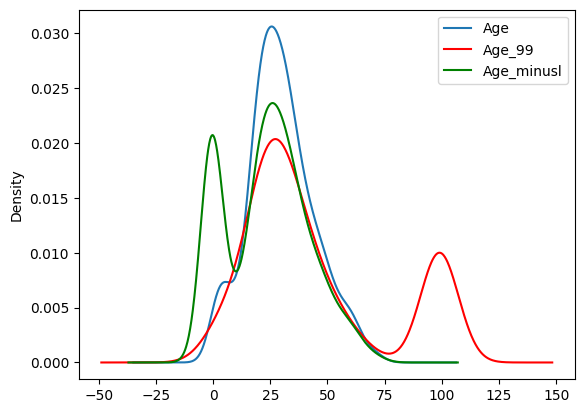

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original Variable Distribution
x_train['Age'].plot(kind='kde', ax=ax)

# Variable imputed with median
x_train['Age_99'].plot(kind='kde', ax=ax, color='red')

# Variable imputed with mean
x_train['Age_minusl'].plot(kind='kde', ax=ax, color='green')

# Add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()

### Review Distribution:- Fare

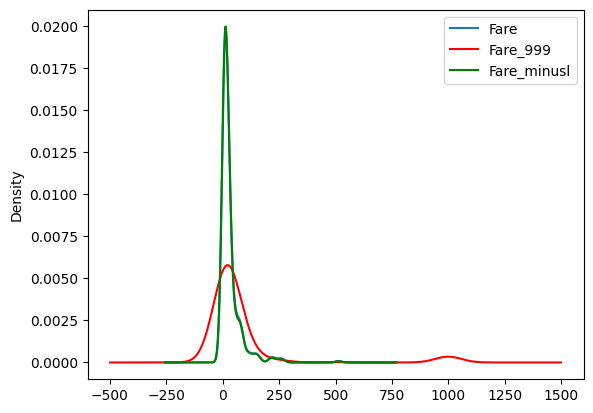

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original Variable Distribution
x_train['Fare'].plot(kind='kde', ax=ax)

# Variable imputed with median
x_train['Fare_999'].plot(kind='kde', ax=ax, color='red')

# Variable imputed with mean
x_train['Fare_minusl'].plot(kind='kde', ax=ax, color='green')

# Add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()

### Check Covariance